# 4.22

### 미니 배치 실습 #1

In [ ]:
import numpy as np
import tensorflow as tf

# 데이터를 학습 데이터와 테스트 데이터로 나눈다.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data() # mnist 훈련데이터 6만개

data_size = x_train.shape[0]
batch_size = 12     # 배치 크기

selected = np.random.choice(data_size, batch_size)
print(selected)
x_batch = x_train[selected]
y_batch = y_train[selected]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[33973 19052 44034 33629 41114 51532  9040  5372 42915 45935 46630 33231]


In [ ]:
# 데이터를 학습 데이터와 테스트 데이터로 나눈다.
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data() # mnist 훈련데이터 6만개

data_size = x_train.shape[0]
batch_size = 32     # 배치 크기

selected = np.random.choice(data_size, batch_size)
print(selected)
x_batch = x_train[selected]
y_batch = y_train[selected]

[ 2821  5075 27337 47682 56525 49084 35717 49349 53423 32692 39785 33882
 58049 58271  6376  3145 56993 25169 18193 44736  2903  2794 42330 31710
 48359 32750 11663 22331 38186 43420 53150 53913]


### 미니 배치의 구현

In [ ]:
import numpy as np

# 시그모이드 함수
def actf(x):
    return 1/(1+np.exp(-x))

In [ ]:
# 시그모이드 함수의 미분치
def actf_deriv(x):
    return x*(1-x)

In [ ]:
# 입력유닛의 개수, 은닉유닛의 개수, 출력유닛의 개수
inputs, hiddens, outputs = 2, 2, 1
learning_rate = 0.5     # 학습률

In [ ]:
# 훈련 입력과 출력(XOR 문제)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
T = np.array([[0], [1], [1], [0]])

In [ ]:
# 가중치를 -1.0에서 1.0 사이의 난수로 초기화한다.
# -> Keras에서는 Dense 레이어의 기본값으로 Glorot uniform을 쓴다.
W1 = 2*np.random.random((inputs, hiddens))-1
W2 = 2*np.random.random((hiddens, outputs))-1
B1 = np.zeros(hiddens)
B2 = np.zeros(outputs)

In [ ]:
# 순방향 전파 계산
def predict(x):
    layer0 = x  # 입력을 layer0에 대입한다.
    Z1 = np.dot(layer0, W1)+B1  # 행렬의 곱을 계산한다.
    layer1 = actf(Z1)   # 활성화 함수를 적용한다.
    Z2 = np.dot(layer1, W2)+B2  # 행렬의 곱을 계산한다.
    layer2 = actf(Z2)   # 활성화 함수를 적용한다.
    return layer0, layer1, layer2

In [ ]:
# 역방향 전파 계산
def fit():
    global W1, W2, B1, B2
    for i in range(60000):  # 6만번 반복
        layer0, layer1, layer2 = predict(X) # 순방향 전파
        layer2_error = layer2 - T  # 손실(오차) 계산
        # 역전파(그래디언트 계산)
        layer2_delta = layer2_error*actf_deriv(layer2)  # 출력층 델타 계산 = 출력층 그래디언트
        layer1_error = np.dot(layer2_delta, W2.T)
        layer1_delta = layer1_error*actf_deriv(layer1)  # 은닉층 델타 계산 = 은닉층 그래디언트
        # SDG 옵티마이저가 그래디언트로 가중치 업데이트
        W2 += -learning_rate*np.dot(layer1.T, layer2_delta)/4.0
        W1 += -learning_rate*np.dot(layer0.T, layer1_delta)/4.0
        B2 += -learning_rate*np.sum(layer2_delta, axis=0)/4.0
        B1 += -learning_rate*np.sum(layer1_delta, axis=0)/4.0

In [ ]:
def test():
    for x, y in zip(X, T):
        x = np.reshape(x, (1, -1))  # 하나여도 2차원 형태여야 한다.
        layer0, layer1, layer2 = predict(x)
        print(x, y, layer2)

fit()
test()

### MNIST 필기체 숫자 데이터 세트

In [ ]:
# 숫자 데이터 가져오기
import matplotlib.pyplot as plt
import tensorflow as tf

(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [ ]:
# 숫자 데이터 표시하기
train_images.shape

(60000, 28, 28)

In [ ]:
train_labels # 오류를 해결해라

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
test_images.shape

(10000, 28, 28)

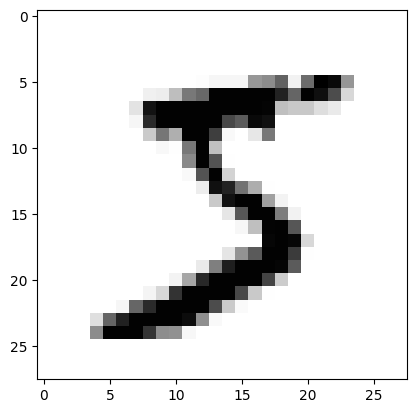

In [ ]:
plt.imshow(train_images[0], cmap="Greys")

In [ ]:
# 신경망 모델 구축하기
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)))
model.add(tf.keras.layers.Dense(10, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 옵티마이저와 손실함수, 지표 등을 정의하는 컴파일 단계
model.compile(optimizer='rmsprop',
              loss='mse',
              metrics=['accuracy'])

In [ ]:
# 데이터 전처리
train_images = train_images.reshape((60000, 784))
train_images = train_images.astype("float32") / 255.0

test_images = test_images.reshape((10000, 784))
test_images = test_images.astype("float32") / 255.0

In [ ]:
# 정답 레이블 형태 변경(원핫 인코딩)
train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

In [ ]:
# 학습
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8743 - loss: 0.0252
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9317 - loss: 0.0129
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9454 - loss: 0.0101
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9550 - loss: 0.0085
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9616 - loss: 0.0074


In [ ]:
# 테스트
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('테스트 정확도:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9731 - loss: 0.0051
테스트 정확도: 0.9731000065803528


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9789 - loss: 0.0043
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9804 - loss: 0.0040
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9817 - loss: 0.0038
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9829 - loss: 0.0036
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9836 - loss: 0.0034


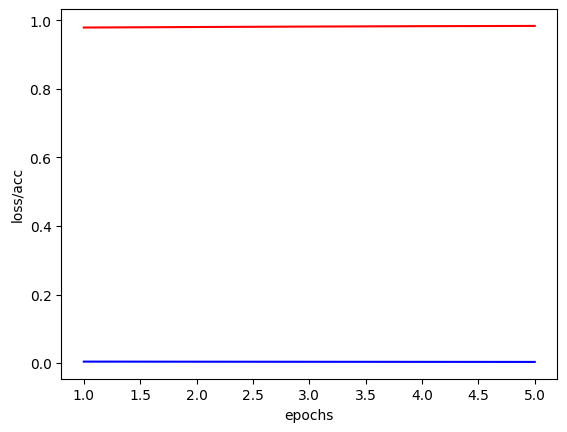

In [ ]:
# 그래프 그리기
history = model.fit(train_images, train_labels, epochs=5, batch_size=128)
loss = history.history['loss']
acc = history.history['accuracy']
epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, acc, 'r', label='Accuracy')
plt.xlabel('epochs')
plt.ylabel('loss/acc')
plt.show()

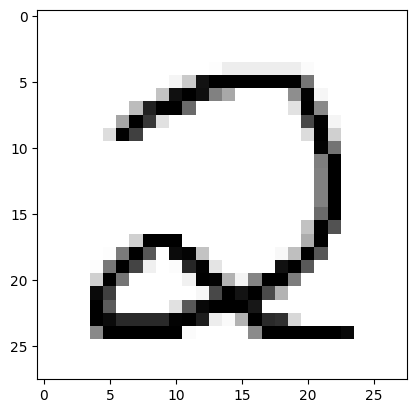

In [ ]:
# 실제 이미지로 테스트하기
import cv2 as cv

image = cv.imread('/content/drive/MyDrive/2026년 1학기/딥러닝프로그래밍/데이터셋/test.png', cv.IMREAD_GRAYSCALE)
image = cv.resize(image, (28, 28))
image = image.astype('float32')
image = image.reshape(1, 784)
image = 255-image
image /= 255.0

plt.imshow(image.reshape(28, 28), cmap='Greys')
plt.show()

In [ ]:
# 테스트
pred = model.predict(image.reshape(1, 784), batch_size=1)
print("추정된 숫자=", pred.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
추정된 숫자= 2


##### 도전문제 (1) 은닉층 유닛의 개수는 성능에 어떻게 영향을 끼치는가? 은닉층 유닛의 개수를 변경하면서 정확도가 어떻게 변하는지를 관찰해보자.

In [ ]:
# 은닉층 유닛 개수
unit_list = [32, 64, 128, 256, 512, 1024]
results = []

for units in unit_list:
    print("\n")
    print("units = ", units)

    # 새로운 모델 생성
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(units, activation='relu', input_shape=(784,)))
    model.add(tf.keras.layers.Dense(10, activation='sigmoid'))

    model.compile(
        optimizer='rmsprop',
        loss='mse',
        metrics=['accuracy']
    )

    # 학습
    model.fit(train_images, train_labels, epochs=5, batch_size=128, verbose=0)

    # 평가
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    print("테스트 정확도:", test_acc)

    results.append(test_acc)



units =  32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


테스트 정확도: 0.9434000253677368


units =  64
테스트 정확도: 0.9495000243186951


units =  128
테스트 정확도: 0.9563000202178955


units =  256
테스트 정확도: 0.9606000185012817


units =  512
테스트 정확도: 0.9625999927520752


units =  1024
테스트 정확도: 0.9641000032424927


In [ ]:
# 결과 출력
i = 0
while i < len(unit_list):
    print("units =", unit_list[i], "-> accuracy =", results[i])
    i += 1

units = 32 -> accuracy = 0.9434000253677368
units = 64 -> accuracy = 0.9495000243186951
units = 128 -> accuracy = 0.9563000202178955
units = 256 -> accuracy = 0.9606000185012817
units = 512 -> accuracy = 0.9625999927520752
units = 1024 -> accuracy = 0.9641000032424927


-> 은닉층 유닛을 증가시키면서 정확도를 관찰한 결과, 유닛 수가 증가할수록 정확도가 상승하였다. 그러나 유닛 개수가 늘어날수록 증가 폭은 미세하게 줄어드는 경향이 있다.

##### 도전문제 (2) 배치 크기를 변경하면서 학습의 정확도가 어떻게 변하는지를 관찰해보자.

In [ ]:
# 배치 크기를 리스트에 저장
batch_list = [32, 64, 128, 256, 512]
results = []

for batch in batch_list:
    print("\n")
    print("batch size =", batch)

    # 새로운 모델 생성
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)))
    model.add(tf.keras.layers.Dense(10, activation='sigmoid'))

    model.compile(optimizer='rmsprop',
                  loss='mse',
                  metrics=['accuracy'])

    # 학습
    model.fit(train_images, train_labels, epochs=5,
              batch_size=batch, verbose=0)

    # 평가
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    print("테스트 정확도:", test_acc)

    results.append(test_acc)



batch size = 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


테스트 정확도: 0.9772999882698059


batch size = 64
테스트 정확도: 0.9735000133514404


batch size = 128
테스트 정확도: 0.9646000266075134


batch size = 256
테스트 정확도: 0.9492999911308289


batch size = 512
테스트 정확도: 0.9330000281333923


In [ ]:
# 결과 출력
i = 0
while i<len(batch_list):
    print("batch size =", batch_list[i], "-> accuracy =", results[i])
    i += 1

batch size = 32 -> accuracy = 0.9772999882698059
batch size = 64 -> accuracy = 0.9735000133514404
batch size = 128 -> accuracy = 0.9646000266075134
batch size = 256 -> accuracy = 0.9492999911308289
batch size = 512 -> accuracy = 0.9330000281333923


-> 배치 크기가 32일 때는 정확도가 약 0.977이었지만, 512일 때는 정확도가 약 0.933으로 배치 크기가 증가할수록 정확도는 오히려 감소한다는 것을 알 수 있다.

##### 도전문제 (3) 은닉층의 활성화 함수를 relu에서 시그모이드 함수로 변경해보자. 학습의 정확도가 어떻게 변하는지를 관찰해보자.

In [ ]:
# 활성화 함수 리스트에 relu와 시그모이드 함수를 저장
act_list = ['relu', 'sigmoid']
results = []

for act in act_list:
    print("\n")
    print("activation =", act)

    # 새로운 모델 생성
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(512, activation=act, input_shape=(784,)))
    model.add(tf.keras.layers.Dense(10, activation='sigmoid'))

    model.compile(optimizer='rmsprop',
                  loss='mse',
                  metrics=['accuracy'])

    # 학습
    model.fit(train_images, train_labels,
              epochs=5,
              batch_size=128,
              verbose=0)

    # 평가
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
    print("테스트 정확도:", test_acc)

    results.append(test_acc)



activation = relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


테스트 정확도: 0.961899995803833


activation = sigmoid
테스트 정확도: 0.9093000292778015


In [ ]:
# 결과 출력
i = 0
while i<len(act_list):
    print("activation =", act_list[i], "-> accuracy =", results[i])
    i += 1

activation = relu -> accuracy = 0.961899995803833
activation = sigmoid -> accuracy = 0.9093000292778015


은닉층의 활성화 함수를 sigmoid로 변경했을 때는 ReLU를 사용할 때보다 정확도가 낮게 나타났다.

### 그리드 검색 예제

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import GridSearchCV
# 최신버전과 호환 관련 정리
!pip install scikit-learn==1.5.1
!pip install scikeras
from scikeras.wrappers import KerasClassifier

In [ ]:
# 데이터 세트 준비
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32')/255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32')/255

train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 신경망 모델 구축
def build_model():
    network = tf.keras.models.Sequential()
    network = tf.keras.models.Sequential()
    network.add(tf.keras.layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
    network.add(tf.keras.layers.Dense(10, activation='sigmoid'))

    network.compile(optimizer='rmsprop',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
    return network

In [ ]:
# 하이퍼 매개변수 딕셔너리
param_grid = {
    'epochs': [1,2,3],  # 에포크 수: 1, 2, 3
    'batch_size': [32, 64]  # 배치 크기: 32, 64
}

In [ ]:
# 케라스 모델을 sklearn에서 사용하도록 포장한다.
model = KerasClassifier(build_fn = build_model,verbose=1)

In [ ]:
# 그리드 검색
gs = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1
)

In [ ]:
# 그리드 검색 결과 출력
grid_result = gs.fit(train_images, train_labels)
print(grid_result.best_score_)
print(grid_result.best_params_)

/usr/local/lib/python3.12/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9396 - loss: 0.2039
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9739 - loss: 0.0854
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9827 - loss: 0.0591
0.97165
{'batch_size': 32, 'epochs': 3}
